In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [3]:
df = pd.read_csv("Churn_Modelling.csv")

print(df.head())

print(df.shape)

print(df.info())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    
    if df[col].dtype == "object":
        
        print("Encoding:", col)
        
        df[col] = le.fit_transform(
            df[col].astype(str)
        )

Encoding: Surname
Encoding: Geography
Encoding: Gender


In [6]:
X = df.drop("Exited", axis=1)

y = df["Exited"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

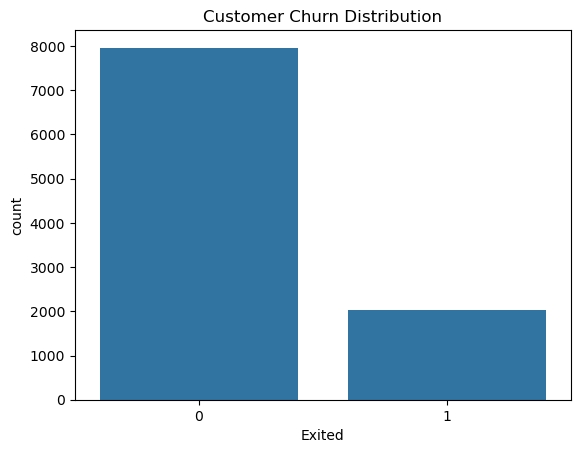

In [8]:
sns.countplot(x="Exited", data=df)

plt.title("Customer Churn Distribution")

plt.show()

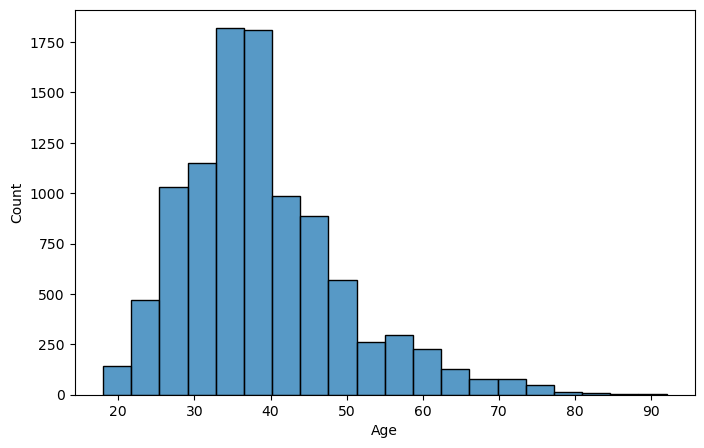

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20)

plt.show()

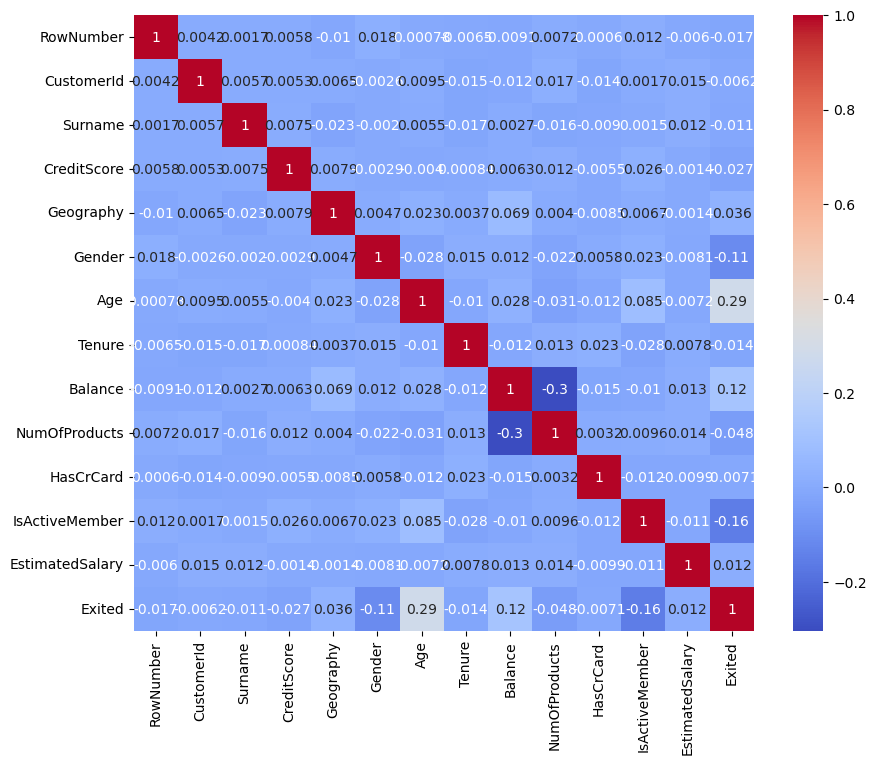

In [10]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

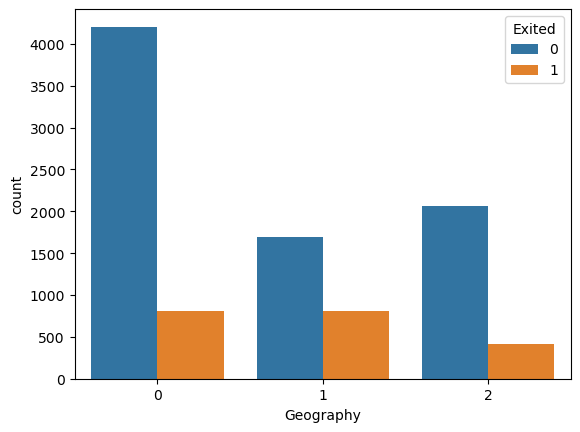

In [11]:
sns.countplot(
    x="Geography",
    hue="Exited",
    data=df
)

plt.show()

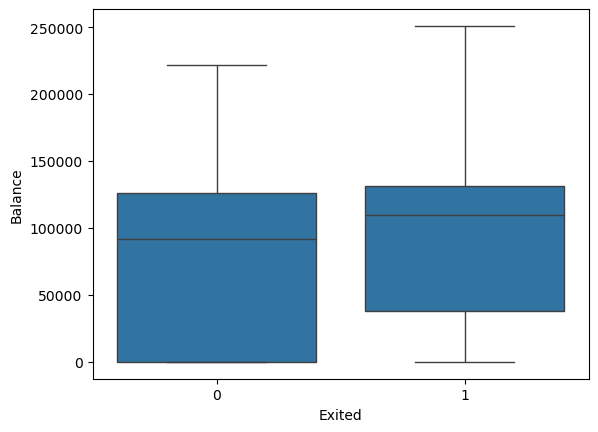

In [12]:
sns.boxplot(
    x="Exited",
    y="Balance",
    data=df
)

plt.show()

In [13]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, pred_lr)
)

print(
    classification_report(
        y_test,
        pred_lr
    )
)

Accuracy: 0.7905
              precision    recall  f1-score   support

           0       0.81      0.97      0.88      1607
           1       0.35      0.07      0.12       393

    accuracy                           0.79      2000
   macro avg       0.58      0.52      0.50      2000
weighted avg       0.72      0.79      0.73      2000



In [14]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(y_test, pred_rf)
)

print(
    classification_report(
        y_test,
        pred_rf
    )
)

Accuracy: 0.8655
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.45      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.86      0.87      0.85      2000



In [15]:
prob = rf.predict_proba(X_test)[:,1]

roc = roc_auc_score(
    y_test,
    prob
)

print("ROC AUC =", roc)

ROC AUC = 0.8596732488745958


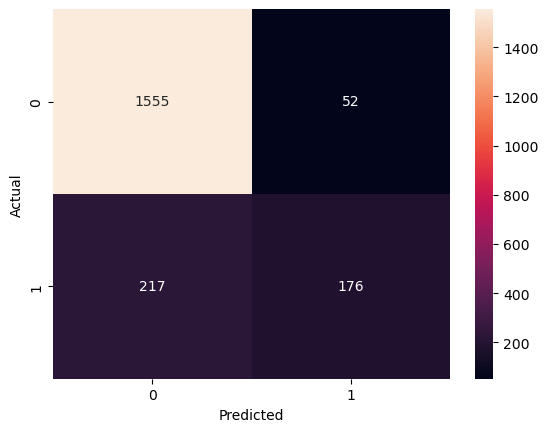

In [16]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [17]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

            Feature  Importance
6               Age    0.198673
9     NumOfProducts    0.123204
8           Balance    0.092099
1        CustomerId    0.088506
12  EstimatedSalary    0.088259
3       CreditScore    0.087915
0         RowNumber    0.086879
2           Surname    0.085813
7            Tenure    0.052671
11   IsActiveMember    0.039834
4         Geography    0.028061
5            Gender    0.015268
10        HasCrCard    0.012820
